# Physically Informed Neural Network for the Acoustic Wave Equation
We aim at building a function $p(x, y, x_0, y_0, t)$ which gives the value of a pressure field evolving through time, subject to an external pressure source, where the pressure wave propagates according to the acoustic wave equation. This function shouldgive the value of the pressure field at a specific spatiotemporal point, when the wave is excited by an external source centered in $(x_0, y_0)$. The acoustic wave equation is given by $$\frac{\partial^2 p}{\partial t^2} = c^2\nabla^2 p + s,$$ where $s$ is the external forcing term. The function $c$ is continuous in space but fixed in time (in the current case, it is a constant function $c=5$ everywhere, but it can be generalized to non-constant functions). 

The function can be approximated by a Neural Network, trained to optimize minimize, for any input $(x, y, x_0, y_0, t)$, the residual $$|\frac{\partial^2 p_{x, y, t}}{\partial t^2} - 5^2\nabla^2 p_{x, y, t} - s_{x, y, x_0, y_0, t}|$$, where the subcript $(x, y, t)$ denotes the evaluation of a function at those coordinates in space and time.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary
import io
import imageio
from IPython.display import display, Image, clear_output
import ipywidgets as widgets

device = "mps"

We define the external source function. It is a Gaussian field centered in $(x_0, y_0)$, multiplied by a Ricker wavelet, whose peak is at $t=1$.

In [2]:
def source(x, y, t, cx=0, cy=0, sigma=.3, amplitude_g=1e2, f=1.0, amplitude_r=1.0, t0=1.0):
    dx, dy = x - cx, y - cy
    gaussian = amplitude_g * torch.exp(-(dx**2/(2*sigma**2)+dy**2/(2*sigma**2)))
    tau = t - t0
    pi2f2tau2 = (torch.pi * f)**2 * tau**2
    ricker = amplitude_r * (1.0 - 2.0 * pi2f2tau2) * torch.exp(-pi2f2tau2)
    return gaussian * ricker

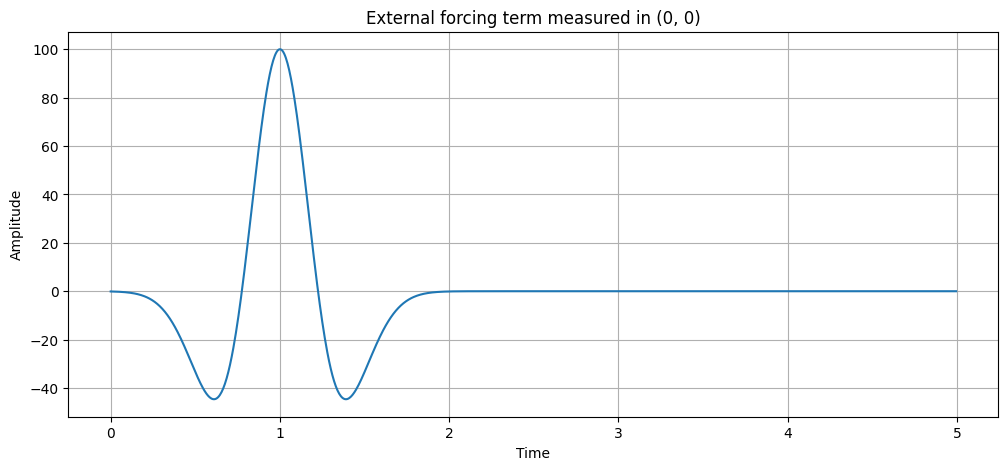

In [3]:
n_t = 1000
plt.figure(figsize=(12, 5))
plt.plot(torch.arange(0, 5, 5/n_t), source(torch.zeros(n_t), torch.zeros(n_t), torch.arange(0, 5, 5/n_t), 0, 0))
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("External forcing term measured in (0, 0)")
plt.grid()
plt.show()

We construct a Finite Difference solver which will serve as reference.

In [4]:
def run_fd_reference(c: float = 5.0, t_max: float = 5.0, n_t: int = 250, L: float = 40.0, dx: float = 0.2, t0=1, cx=0, cy=0):
    dt = t_max / n_t
    cfl = c * dt / dx
    assert cfl < 1 / np.sqrt(2), f"CFL = {cfl:.3f} unstable, reduce dt or increase dx"
    nx = int(2 * L / dx) + 1
    x1d = np.linspace(-L, L, nx)
    X, Y = np.meshgrid(x1d, x1d, indexing="ij")
    r2 = (c * dt / dx) ** 2
    p_prev = np.zeros((nx, nx))
    p_curr = np.zeros((nx, nx))
    def idx(v): return int(round((v + L) / dx))
    rec_pts = {
        "(-2,0)": (idx(-1.0), idx(0.0)),
        "(0,1)":  (idx( 0.0), idx(0.0)),
        "(0.5,0)":  (idx( 1.0), idx(0.0)),
    }
    traces = {k: np.zeros(n_t) for k in rec_pts}
    t_arr  = np.linspace(0, t_max, n_t)
    it = 0
    for t in (t_arr):
        lap = (p_curr[2:, 1:-1] + p_curr[:-2, 1:-1] + p_curr[1:-1, 2:] + p_curr[1:-1, :-2] - 4.0 * p_curr[1:-1, 1:-1])
        src = source(torch.tensor(X), torch.tensor(Y), torch.tensor(t), t0=t0, cx=cx, cy=cy).numpy()[1:-1, 1:-1]
        p_next = np.zeros_like(p_curr)
        p_next[1:-1, 1:-1] = (2.0 * p_curr[1:-1, 1:-1] - p_prev[1:-1, 1:-1] + r2 * lap+ dt ** 2 * src)
        for k, (ix, iy) in rec_pts.items():
            traces[k][it] = p_next[ix, iy]
        p_prev, p_curr = p_curr, p_next
        it += 1
    return t_arr, traces

We design a function to check specific seismograms produced by querying the model:

In [5]:
gif_frames = []
GIF_PATH   = "training_progress.gif"
_gif_display_handle = None

receiver_labels=["(-2,0)", "(0,1)", "(0.5,0)"]

def check_seismograms(model, c_val: float = 5.0, t_max: float = 5.0,
                      n_t: int = 500, t_0=1, cx=0, cy=0):
    global gif_frames, _gif_display_handle
    x  = torch.ones(n_t, 1, device=device)
    y  = torch.zeros(n_t, 1, device=device)
    t  = torch.linspace(0, t_max, n_t, device=device).unsqueeze(1)
    t_np     = t.squeeze().cpu().numpy()
    fig, axes = plt.subplots(len(t_0), 3, figsize=(15, 4*len(t_0)))
    if len(t_0) == 1:
        axes = [axes]
    for i in range(len(t_0)):
        t_fd, fd_seis = run_fd_reference(c_val, t_max, n_t, t0=t_0[i], cx=cx, cy=cy)
        t0 = torch.ones_like(t, device=device) * t_0[i]
        with torch.no_grad():
            p_neg1 = model(-2*x, y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_zero = model(0*x, x, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            p_pos1 = model(0.5*x, y, t, torch.zeros_like(x), torch.zeros_like(y), t0).squeeze().cpu().numpy()
            pinn_seis = {'(-2,0)': p_neg1, '(0,1)': p_zero, '(0.5,0)': p_pos1}
        for ax, label in zip(axes[i], receiver_labels):
            ax.plot(t_np, pinn_seis[label], label='PINN',   linewidth=1.5)
            ax.plot(t_fd, fd_seis[label],   label='FD ref', linewidth=1.5,
                    linestyle='--', color='tomato')
            ax.set_title(f"Receiver {label}")
            ax.set_xlabel("Time")
            ax.set_ylabel("Amplitude")
            ax.set_xlim([0, t_max])
            ax.set_ylim([-.4, .75])
            ax.legend()
            ax.grid(True)
    fig.suptitle(
        f"Seismograms — c={c_val}  src=({cx},{cy})  "
        f"Iteration {(len(gif_frames)+1)*200}  (PINN vs FD reference)",
        fontsize=13,
    )
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=80)
    buf.seek(0)
    gif_frames.append(buf.read())
    plt.close(fig)
    if len(gif_frames) >= 1:
        import imageio.v2 as iio2
        imgs = [iio2.imread(io.BytesIO(f)) for f in gif_frames]
        
        with iio2.get_writer(GIF_PATH, mode="I", loop=0) as writer:
            for i, img in enumerate(imgs):
                repeats = 4 if i == len(imgs) - 1 else 1
                for _ in range(repeats):
                    writer.append_data(img, {"duration": 40})
    gif_bytes = open(GIF_PATH, "rb").read()
    if _gif_display_handle is None:
        _gif_display_handle = display(
            Image(data=gif_bytes, format="gif"),
            display_id="seismo_gif"
        )
    else:
        _gif_display_handle.update(Image(data=gif_bytes, format="gif"))

We train the PINN. To do so, we sample random points $x, y, t$, alongside with random values $c$, and we compute the loss of the output produced by the PINN. $x, y$ are sampled in $[-1, 1]$, $t$ is sampled in $[0, 10]$ and $c$ is sampled in $[0.02, 2.02]$. Since we want to overfit the loss function, we purposely chose a small learning rate. Also, it is well-known that PINN's require a really long training for convergence.

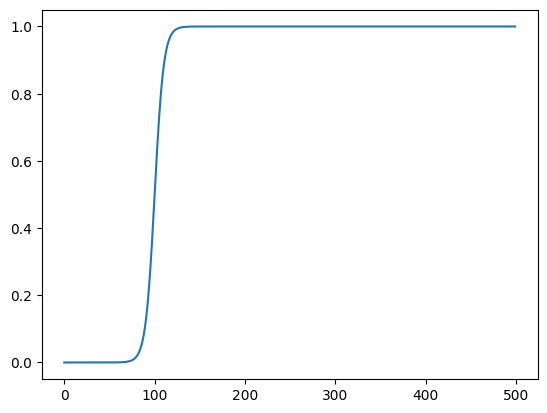

In [6]:
def g(t, alpha=10.0):
    return 0.5*(torch.tanh(alpha*(t+1))+1)

plt.plot(g(torch.arange(0, 5, 0.01)-2))

In [ ]:
class SeparablePINN(nn.Module):
    def __init__(self, rank=16, width=64, depth=4):
        super().__init__()
        self.rank = rank

        def subnet(in_dim):
            layers = [nn.Linear(in_dim, width), nn.Tanh()]
            for _ in range(depth - 1):
                layers += [nn.Linear(width, width), nn.Tanh()]
            layers += [nn.Linear(width, rank)]
            return nn.Sequential(*layers)
        self.net_x = subnet(2)
        self.net_y = subnet(2)
        self.net_t = subnet(2)
        self.net_d = subnet(2)
        self.last_network = nn.Sequential(nn.Linear(4*rank, 16), nn.Tanh(), nn.Linear(16, 1))
    def forward(self, x, y, t, x0, y0, t0):
        X = self.net_x(torch.cat([x, x0], dim=-1))
        Y = self.net_y(torch.cat([y, y0], dim=-1))
        T = self.net_t(torch.cat([t, t0], dim=-1))
        D = self.net_d(torch.cat([((x-x0)**2 + (y-y0)**2), t-t0], dim=-1))
        p = self.last_network(torch.cat([X, Y, T, D], dim=-1).squeeze())
        return p * g(t-t0)

def loss_fn(model, x, y, t, x0, y0, t0):
    pred = model(x, y, t, x0, y0, t0)
    s_xyt = source(x, y, t, cx=x0, cy=y0, t0=t0)
    ones = torch.ones_like(pred)
    dp_dx, dp_dy, dp_dt = torch.autograd.grad(pred, [x, y, t], grad_outputs=ones, create_graph=True)
    dp_dxx = torch.autograd.grad(dp_dx, x, grad_outputs=ones, create_graph=True)[0]
    dp_dyy = torch.autograd.grad(dp_dy, y, grad_outputs=ones, create_graph=True)[0]
    dp_dtt = torch.autograd.grad(dp_dt, t, grad_outputs=ones, create_graph=True)[0]
    pde_res = dp_dtt - (5**2) * (dp_dxx + dp_dyy) - s_xyt
    return (pde_res**2).mean()
    
model = SeparablePINN(rank=32, width=16, depth=2)
summary(model, [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1), (1, 1)])
model = model.to(device)

gif_frames.clear()
_gif_display_handle = None
V = 1.0
N_POINTS = int(1e4)
SPATIAL_RANGE = 5.0
T0_MIN = 0.5
T0_MAX = 6.5
T_MAX = 7.0
N_STEPS = 300_000
LR = 1e-3
CKPT_EVERY = 2

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=200, T_mult=2, eta_min=1e-5)
def rnd(*shape):
    return torch.rand(*shape, 1, device=device)

for step in (pbar := tqdm(range(N_STEPS//100))):
    step_loss = 0
    for small_step in range(100):
        optimizer.zero_grad()
        x  = (rnd(N_POINTS) - 0.5) * 2 * SPATIAL_RANGE
        y  = (rnd(N_POINTS) - 0.5) * 2 * SPATIAL_RANGE
        x0 = (rnd(N_POINTS) - 0.5) * 2 * SPATIAL_RANGE
        y0 = (rnd(N_POINTS) - 0.5) * 2 * SPATIAL_RANGE
        t0 = (rnd(N_POINTS) * T0_MAX) + 1.0
        t = (rnd(N_POINTS)) * T_MAX
        x  = x.requires_grad_(True)
        y  = y.requires_grad_(True)
        t  = t.requires_grad_(True)
        loss_pde = loss_fn(model, x, y, t, x0, y0, t0)
        loss_pde.backward()
        optimizer.step()
        step_loss += loss_pde
    pbar.set_description(f"loss={step_loss.item()/100:.3e} l_r={scheduler.get_last_lr()[0]:.3e}")
    scheduler.step()
    if step % CKPT_EVERY == 0:
        check_seismograms(model, t_0=[1.5])
torch.save(model, "model.pt")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 16]              48
              Tanh-2                [-1, 1, 16]               0
            Linear-3                [-1, 1, 16]             272
              Tanh-4                [-1, 1, 16]               0
            Linear-5                [-1, 1, 32]             544
            Linear-6                [-1, 1, 16]              48
              Tanh-7                [-1, 1, 16]               0
            Linear-8                [-1, 1, 16]             272
              Tanh-9                [-1, 1, 16]               0
           Linear-10                [-1, 1, 32]             544
           Linear-11                [-1, 1, 16]              48
             Tanh-12                [-1, 1, 16]               0
           Linear-13                [-1, 1, 16]             272
             Tanh-14                [-1

  0%|          | 0/3000 [00:00<?, ?it/s]